In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

import os
import time

from collections.abc import Callable
from dataclasses import asdict
from pathlib import Path
from typing import TYPE_CHECKING, Any

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn

from torch.amp.autocast_mode import autocast
from torch.amp.grad_scaler import GradScaler
from torch.optim import Adam
from tqdm import tqdm

from experiments.plotting import (
    _plot_SRE_distribution,
    plot_training_curves,
    view_correlation,
)
from GNN.parameter_search.helpers import objective_GNN, objective_NN
from GNN.physics_aware_NN import GNN, NN, Regressor
from GNN.training.datasets import build_loaders, build_loaders_NN
from GNN.training.train import build_loss, train_model
from GNN.training.train_config import TrainConfig
from GNN.training.utils import (
    collect_dataset_indices,
    collect_dataset_paths,
    evaluate_loss,
    evaluate_r2,
    to_scalar,
    unpack_supervised_batch,
)
from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
)
from scripts.train_model import PARAMS
from src.utils import configure_logger

if TYPE_CHECKING:
    from torch_geometric.loader import DataLoader

from GNN.training.train import build_loss, TrainHistory, _run_train_epoch
from GNN.training.runners import _resolve_model_save_path

In [3]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

In [4]:
model_type="gnn"
epochs = 20
lr = 1.5131621801102364e-05
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "haar"  # required if training_mode == "per_family"
target = "sre"
training_data_dir = "../outputs/data/datasets_SRE"
target_variant = "sre_density"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
model_save_path = f"../notebooks/outputs/models/final/{family}_model_{model_type}_{training_mode}_{target_variant}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100

split = "target"  # "target" | "family"

In [5]:
training(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    target_variant=target_variant,
    model_type=model_type,
    model_hparams=None,
    train_hparams=None,
    training_data_dir=training_data_dir,
    split=split,
    model_save_path=model_save_path,
    show_progress=True,
    show_val_progress=False,
    log_every_n_batches=10,
    heartbeat_secs=60.0,
    epoch_time_warning_secs=600.0,
)

2026-07-01 10:49:41,837 - GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=haar | loss_type=huber
2026-07-01 10:49:41,838 - GNN.training.runners - INFO - Training configuration done.
2026-07-01 10:49:41,839 - GNN.training.runners - INFO - Collecting data paths...
2026-07-01 10:49:41,840 - GNN.training.runners - INFO - Found 1 data paths.
2026-07-01 10:49:41,841 - GNN.training.runners - INFO - Data paths collected.
2026-07-01 10:49:41,842 - GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-07-01 10:50:52,521 - GNN.training.runners - INFO - Loaders built | train_loader=25704 graphs | val_loader=2856 graphs | test_loader=7140 graphs
2026-07-01 10:50:52,561 - GNN.training.runners - INFO - Loaders and model built.
2026-07-01 10:50:52,561 - GNN.training.runners - INFO - Starting training...
2026-07-01 10:50:52,563 - GNN.training.train - INFO - Using device: cuda
2026-07-01 10:50:52,743 - GNN.training.train 

Epoch 1/20:  55%|█████▍    | 883/1607 [01:00<00:53, 13.47it/s, loss=0.0051, graphs=14160]

2026-07-01 10:51:52,790 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 885/1607 | loss 0.005149 | elapsed 60.0s | graphs 14160


2026-07-01 10:52:44,608 - GNN.training.train - INFO - Training complete (111.9s) | running validation...


2026-07-01 10:52:56,242 - GNN.training.train - INFO - Losses | train 0.003817 | val 0.002029 | lr 5.46e-04 | time train=111.9s val=11.6s total=123.5s
2026-07-01 10:52:56,244 - GNN.training.train - INFO - -------- EPOCH 002 --------


...

2026-07-01 11:26:49,469 - GNN.training.train - INFO - Losses | train 0.001347 | val 0.001248 | lr 2.73e-04 | time train=103.6s val=9.8s total=113.4s
2026-07-01 11:26:49,471 - GNN.training.train - INFO - -------- EPOCH 020 --------


Epoch 20/20:  59%|█████▉    | 952/1607 [01:00<00:43, 14.99it/s, loss=0.0013, graphs=15264]

2026-07-01 11:27:49,500 - GNN.training.train - INFO - [Heartbeat] Epoch 20 batch 954/1607 | loss 0.001325 | elapsed 60.0s | graphs 15264


2026-07-01 11:28:30,832 - GNN.training.train - INFO - Training complete (101.4s) | running validation...


2026-07-01 11:28:40,490 - GNN.training.train - INFO - Losses | train 0.001348 | val 0.001213 | lr 2.73e-04 | time train=101.4s val=9.7s total=111.0s
2026-07-01 11:31:11,818 - GNN.training.runners - INFO - Training complete.
2026-07-01 11:31:11,950 - experiments.plotting - INFO - Saved training curve plot to outputs\figures\training_curves\training_curves_gnn_huber_haar_7.png
2026-07-01 11:31:11,961 - GNN.training.runners - INFO - Saved model checkpoint to ..\notebooks\outputs\models\final\haar_model_gnn_per_family_sre_density.pt
2026-07-01 11:31:12,007 - scripts.train_model - INFO - Final test loss: 0.001206
2026-07-01 11:31:12,007 - scripts.train_model - INFO - Test R2 score: 0.9617
2026-07-01 11:31:12,008 - scripts.train_model - INFO - Validation R2 score: 0.9609
2026-07-01 11:31:12,010 - scripts.train_model - INFO - Training R2 score: 0.9627


In [6]:
training_scope = "family" if training_mode == "per_family" else "global"
model_save_path = model_save_path
batch_size = PARAMS.get(family, {}).get("batch_size", batch_size)
predictions(
    model_path=model_save_path,
    model_kind=model_type,
    training_scope=training_scope,
    target_variant=target_variant,
    loss_type=loss_type,
    model_family=family,
    dataset_root=training_data_dir,
    dataset_family=family,
    batch_size=batch_size,
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    plot_n_layers=plot_layers,
    plot_n_qubits=plot_qubits,
    split_by_family=True,
    show_progress=True,
)

2026-07-01 11:31:13,377 - scripts.predictions - INFO - Loading checkpoint: ../notebooks/outputs/models/final/haar_model_gnn_per_family_sre_density.pt
2026-07-01 11:31:13,379 - scripts.predictions - INFO - Using target_variant from checkpoint: sre_density
2026-07-01 11:31:13,387 - scripts.predictions - INFO - Found 1 prediction files
Predicting (gnn): 100%|██████████| 7810/7810 [10:13<00:00, 12.73batch/s]
2026-07-01 11:42:27,289 - scripts.predictions - INFO - Saved 124950 predictions to outputs/predictions/family/gnn_predictions_haar.csv


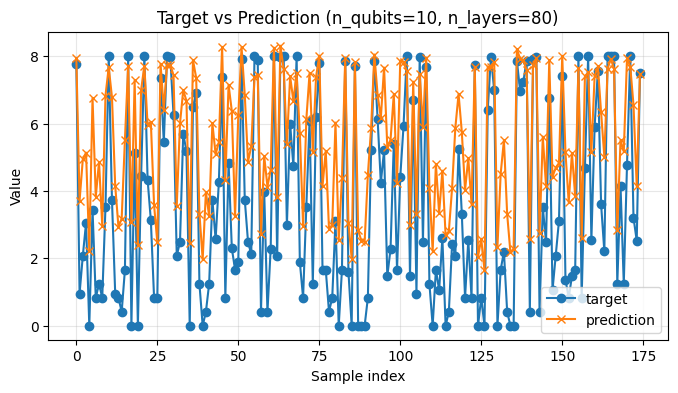

Pearson r = 0.9259


Text(0.5, 1.0, 'True vs Predicted SRE for clifford Family (GNN Model)')

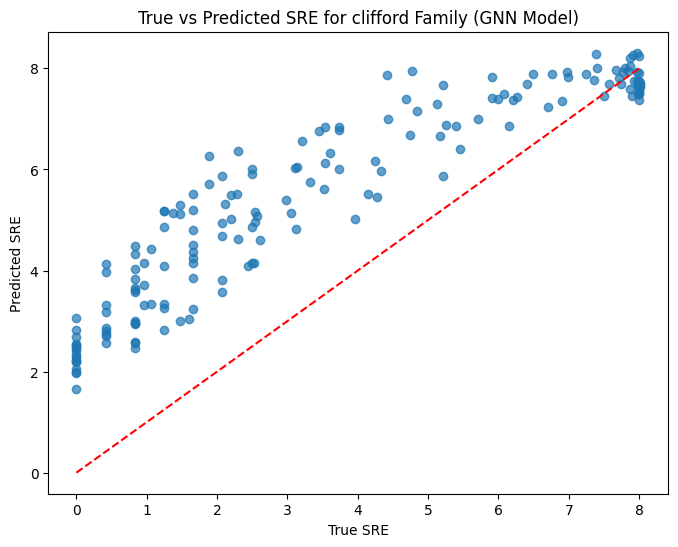

In [27]:
plot_qubits = 10
plot_layers = 80
df = pd.read_csv(f"outputs/predictions/family/gnn_predictions_{family}.csv")
# df = pd.read_csv(f"../notebooks/final/predictions/gnn_predictions_{family}.csv")
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)

new_df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]

nq=plot_qubits
nl=plot_layers

if target_variant == "sre_density":
    new_df["target_sre"] = new_df["target_sre"] * nq

# print(new_df["target_sre"].describe())
# print(new_df["predicted_sre"].describe())

# df = df[(df["n_qubits"] == plot_qubits)]

view_correlation(
    new_df,
    nq=plot_qubits,
    nl=plot_layers,
    col_x="target_sre",
    col_y="predicted_sre",
)
# df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
plt.figure(figsize=(8, 6))
plt.scatter(new_df["target_sre"], new_df["predicted_sre"], alpha=0.7)
plt.plot([new_df["target_sre"].min(), new_df["target_sre"].max()], [new_df["target_sre"].min(), new_df["target_sre"].max()], "r--")  # y=x line
plt.xlabel("True SRE")
plt.ylabel("Predicted SRE")
plt.title(f"True vs Predicted SRE for {family} Family (GNN Model)")

## Test datasets

In [12]:
from GNN.training.datasets import prepare_datasets, make_loaders

In [34]:
family = "haar"
seed = 42
train_split = 0.8
val_split = 0.1
num_workers = 0

In [35]:
family_filter = family if training_mode == "per_family" else None
family_projection = family if training_mode == "per_family" else None

In [36]:
train_paths = collect_dataset_indices(
    training_data_dir,
    family=family_filter,
)

print(f"Collected {len(train_paths)} training paths for family '{family}'.")

Collected 1 training paths for family 'haar'.


In [37]:
prepared = prepare_datasets(
    train_paths,
    loader_kind="gnn",
    seed=seed,
    train_split=train_split,
    val_split=val_split,
    family_projection=family_projection,
    target_variant=target_variant,
    split = split,
)

train_loader, val_loader, test_loader = make_loaders(
    prepared,
    batch_size=batch_size,
    num_workers=num_workers,
)

In [38]:
prepared.base_dataset[0]

Data(
  x=[12, 23],
  edge_index=[2, 8],
  global_features=[1, 2],
  y=[1],
  sre=[1],
  cid='haar_q004_L001_s822089',
  family='haar',
  regime='medium_full',
  n_qubits=[1],
  n_layers=[1],
  seed=[1],
  has_target=[1],
  backend='pennylane',
  method='fwht',
  representation='dense',
  n_bins=[1],
  count_haar_count=[1],
  count_haar_eig_bin_1=[1],
  count_haar_eig_bin_2=[1],
  count_haar_eig_bin_3=[1],
  count_haar_eig_bin_4=[1],
  count_haar_eig_bin_5=[1],
  count_haar_eig_bin_6=[1],
  count_haar_eig_bin_7=[1],
  count_haar_eig_bin_8=[1],
  count_haar_eig_bin_9=[1],
  count_haar_eig_bin_10=[1],
  count_haar_eig_bin_11=[1],
  count_haar_eig_bin_12=[1],
  count_haar_eig_bin_13=[1],
  count_haar_eig_bin_14=[1],
  count_haar_eig_bin_15=[1],
  count_haar_eig_bin_16=[1],
  count_haar_eig_bin_17=[1],
  count_haar_eig_bin_18=[1],
  count_haar_eig_bin_19=[1],
  count_haar_eig_bin_20=[1],
  count_haar_eig_bin_21=[1],
  count_haar_eig_bin_22=[1],
  count_haar_eig_bin_23=[1],
  count_haar_eig

In [44]:
from GNN.physics_aware_NN import ShardedQuantumCircuitGraphDataset
dataset = ShardedQuantumCircuitGraphDataset(["../outputs/temp_data/datasets_SRE/haar/index_haar.jsonl"])
sample = dataset[0]
print("Gate counts:", getattr(sample, 'gate_counts', 'MISSING'))
print("Global features shape:", sample.global_features.shape)

Gate counts: {'haar_count': tensor([0]), 'haar_eig_bin_1': tensor([0]), 'haar_eig_bin_10': tensor([0]), 'haar_eig_bin_11': tensor([0]), 'haar_eig_bin_12': tensor([0]), 'haar_eig_bin_13': tensor([0]), 'haar_eig_bin_14': tensor([0]), 'haar_eig_bin_15': tensor([0]), 'haar_eig_bin_16': tensor([0]), 'haar_eig_bin_17': tensor([0]), 'haar_eig_bin_18': tensor([0]), 'haar_eig_bin_19': tensor([0]), 'haar_eig_bin_2': tensor([0]), 'haar_eig_bin_20': tensor([0]), 'haar_eig_bin_21': tensor([0]), 'haar_eig_bin_22': tensor([0]), 'haar_eig_bin_23': tensor([0]), 'haar_eig_bin_24': tensor([0]), 'haar_eig_bin_25': tensor([0]), 'haar_eig_bin_26': tensor([0]), 'haar_eig_bin_27': tensor([0]), 'haar_eig_bin_28': tensor([0]), 'haar_eig_bin_29': tensor([0]), 'haar_eig_bin_3': tensor([0]), 'haar_eig_bin_30': tensor([0]), 'haar_eig_bin_31': tensor([0]), 'haar_eig_bin_32': tensor([0]), 'haar_eig_bin_33': tensor([0]), 'haar_eig_bin_34': tensor([0]), 'haar_eig_bin_35': tensor([0]), 'haar_eig_bin_36': tensor([0]), 'h